# Ejercicio 1 — Regresión lineal simple y múltiple

**Introducción al Machine Learning — Cuarta lista de ejercicios — Daniel Vargas**

Se usa `experimento_1.csv` (columnas `x1`, `x2`, `y`). Se ajustan tres modelos
de regresión lineal con intercepto: `x1 -> y`, `x2 -> y`, `(x1,x2) -> y`,
usando únicamente las funciones de `src/lista4/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lista4.data import cargar_csv, obtener_xy
from lista4.models import ajustar_regresion_lineal
from lista4.metrics import riesgo_cuadratico

df1 = cargar_csv('experimento_1.csv')
df1.head()

,x1,x2,y
0,0.304717,1.727350,1.429562
1,-1.039984,-1.533861,-3.697491
2,0.750451,0.863828,3.525801
3,0.940565,-0.328525,2.194107
4,-1.951035,-0.061324,-6.489721


## (a) Tabla con intercepto, coeficientes y riesgo empírico de los 3 modelos

In [2]:
X_x1, y = obtener_xy(df1, 'x1', 'y')
X_x2, _ = obtener_xy(df1, 'x2', 'y')
X_amb, _ = obtener_xy(df1, ['x1', 'x2'], 'y')

modelo_x1 = ajustar_regresion_lineal(X_x1, y)
modelo_x2 = ajustar_regresion_lineal(X_x2, y)
modelo_amb = ajustar_regresion_lineal(X_amb, y)

R_x1 = riesgo_cuadratico(y, modelo_x1.predict(X_x1))
R_x2 = riesgo_cuadratico(y, modelo_x2.predict(X_x2))
R_amb = riesgo_cuadratico(y, modelo_amb.predict(X_amb))

tabla_1a = pd.DataFrame([
    {'modelo': 'x1 -> y', 'intercepto': modelo_x1.intercept_,
     'coef_x1': modelo_x1.coef_[0], 'coef_x2': np.nan, 'riesgo_empirico': R_x1},
    {'modelo': 'x2 -> y', 'intercepto': modelo_x2.intercept_,
     'coef_x1': np.nan, 'coef_x2': modelo_x2.coef_[0], 'riesgo_empirico': R_x2},
    {'modelo': '(x1,x2) -> y', 'intercepto': modelo_amb.intercept_,
     'coef_x1': modelo_amb.coef_[0], 'coef_x2': modelo_amb.coef_[1], 'riesgo_empirico': R_amb},
])
tabla_1a

,modelo,intercepto,coef_x1,coef_x2,riesgo_empirico
0,x1 -> y,-0.082506,2.92046,NaN,1.020069
1,x2 -> y,-0.202971,NaN,-0.044049,8.374587
2,"(x1,x2) -> y",-0.083790,2.92513,-0.131194,1.002351


## (b) Correlaciones

In [3]:
corr_x1_y = np.corrcoef(df1['x1'], df1['y'])[0, 1]
corr_x2_y = np.corrcoef(df1['x2'], df1['y'])[0, 1]
corr_x1_x2 = np.corrcoef(df1['x1'], df1['x2'])[0, 1]

print('corr(x1, y)  =', corr_x1_y)
print('corr(x2, y)  =', corr_x2_y)
print('corr(x1, x2) =', corr_x1_x2)

corr(x1, y)  = 0.9371359656907724
corr(x2, y)  = -0.0154496727944874
corr(x1, x2) = 0.032563224619121305


## (c) y contra x1 y y contra x2, con la recta ajustada

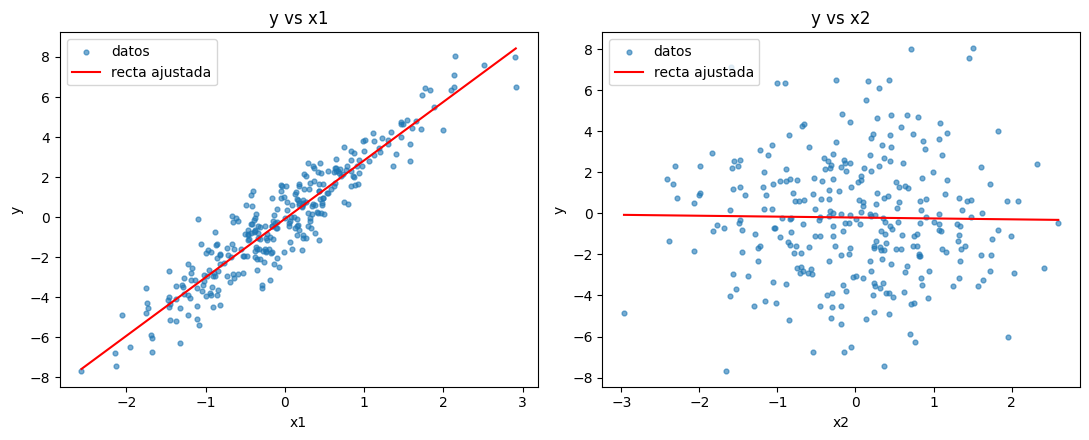

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

xx1 = np.linspace(df1['x1'].min(), df1['x1'].max(), 200).reshape(-1, 1)
axes[0].scatter(df1['x1'], df1['y'], s=12, alpha=0.6, label='datos')
axes[0].plot(xx1, modelo_x1.predict(xx1), color='red', label='recta ajustada')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('y')
axes[0].set_title('y vs x1')
axes[0].legend()

xx2 = np.linspace(df1['x2'].min(), df1['x2'].max(), 200).reshape(-1, 1)
axes[1].scatter(df1['x2'], df1['y'], s=12, alpha=0.6, label='datos')
axes[1].plot(xx2, modelo_x2.predict(xx2), color='red', label='recta ajustada')
axes[1].set_xlabel('x2'); axes[1].set_ylabel('y')
axes[1].set_title('y vs x2')
axes[1].legend()

fig.tight_layout()
plt.show()

## (d) ¿Cuál variable conservaría?

Criterio: menor riesgo empírico entre los dos modelos de una sola variable
(`x1 -> y` vs `x2 -> y`).

In [5]:
if R_x1 < R_x2:
    conclusion_d = 'x1'
else:
    conclusion_d = 'x2'

print(f'R_S(x1 -> y) = {R_x1:.4f}')
print(f'R_S(x2 -> y) = {R_x2:.4f}')
print('Variable que se conservaria:', conclusion_d)

R_S(x1 -> y) = 1.0201
R_S(x2 -> y) = 8.3746
Variable que se conservaria: x1


**Respuesta.** Como $\hat R_S(x_1\to y) < \hat R_S(x_2\to y)$, se conservaría
**x1**: produce menor riesgo empírico por sí sola que x2, es decir, explica
mejor a y cuando solo se puede usar una variable.